In [36]:
print('hello teacher')

hello teacher


In [37]:
!pip install -q pandas numpy pyreadstat scikit-learn xgboost shap matplotlib seaborn scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# CHW Stunting Prediction — Model Training Pipeline
## Two-Stage XGBoost Tuning with Optimal Threshold Optimization

**Objectives:**
- Build a machine learning model to predict child stunting
- Compare baseline models (Logistic Regression, Random Forest) vs XGBoost
- Optimize decision threshold to balance recall (catch stunted children) and precision
- Achieve: Recall ≥0.75, Precision 0.55-0.65, F1 ≥0.65

**Key Experiments:**
1. **Experiment 1 (MAIN)**: Baseline → Tuned → Threshold
   - Compare Logistic Regression, Random Forest, XGBoost
   - Tune XGBoost with optimal threshold
2. **Experiment 2**: Threshold Comparison (0.50 vs optimal)
   - Demonstrate precision-recall tradeoff
3. **Experiment 3**: Feature Engineering Impact
   - Validate engineered features vs raw features

---
## SETUP & CONFIGURATION

In [38]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ML & Evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

# XGBoost & Interpretability
import xgboost as xgb
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


In [39]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_PATH    = os.path.join('data', 'combined_data.csv')
MODELS_DIR   = 'models'
RANDOM_SEED  = 42
RECALL_TARGET = 0.75   # minimum recall we want from the final model

# Feature columns
CAT_COLS = ['region', 'country']
NUM_COLS = [
    'child_age_months', 'child_sex', 'birth_weight_grams',
    'mother_age', 'mother_education', 'mother_bmi',
    'wealth_index', 'water_source', 'sanitation_type',
    'household_size', 'urban_rural',
    'mother_height_cm', 'birth_interval_months',
    'delivery_place', 'birth_size_perceived',
    'birth_order', 'antenatal_visits', 'first_born',
]
RAW_FEATURE_COLS = NUM_COLS + CAT_COLS
TARGET_COL = 'stunted'

# Create models directory
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'Configuration set:')
print(f'  Data path: {DATA_PATH}')
print(f'  Models dir: {MODELS_DIR}')
print(f'  Recall target: ≥{RECALL_TARGET}')
print(f'  Raw features: {len(RAW_FEATURE_COLS)}')

Configuration set:
  Data path: data\combined_data.csv
  Models dir: models
  Recall target: ≥0.75
  Raw features: 20


---
## HELPER FUNCTIONS
### Feature Engineering, Encoding, and Evaluation Functions

In [40]:
# ── FEATURE ENGINEERING ──────────────────────────────────────────────────────
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Add interaction and composite features capturing maternal health,
    birth conditions, and socioeconomic factors.
    """
    X = X.copy()

    # ── Original features (v2-v3) ────────────────────────────────────────────
    X['age_sq'] = X['child_age_months'] ** 2
    X['age_x_poverty'] = X['child_age_months'] * (6 - X['wealth_index'])
    X['age_x_low_edu'] = X['child_age_months'] * (3 - X['mother_education'])
    X['mother_risk'] = (
        (X['mother_education'] == 0).astype(float) +
        (X['mother_bmi'] < 18.5).astype(float)
    )
    X['env_risk'] = X['water_source'] + X['sanitation_type']

    # Stunting-specific features
    if 'mother_height_cm' in X.columns:
        X['mother_short'] = (X['mother_height_cm'] < 150).astype(float)

    birth_risk = pd.Series(0.0, index=X.index)
    if 'birth_weight_grams' in X.columns:
        birth_risk += (X['birth_weight_grams'] < 2500).astype(float)
    if 'birth_size_perceived' in X.columns:
        birth_risk += (X['birth_size_perceived'] >= 4).astype(float)
    X['birth_risk'] = birth_risk

    if 'birth_interval_months' in X.columns and 'first_born' in X.columns:
        X['short_interval'] = (
            (X['birth_interval_months'] < 24) & (X['first_born'] == 0)
        ).astype(float)

    # ── New v4: Maternal × Birth interactions ─────────────────────────────
    if 'birth_risk' in X.columns:
        X['mother_age_x_birth_risk'] = X['mother_age'] * X['birth_risk']

    if 'mother_height_cm' in X.columns and 'birth_weight_grams' in X.columns:
        X['mother_short_x_low_bw'] = X['mother_short'] * (X['birth_weight_grams'] < 2500).astype(float)

    if 'antenatal_visits' in X.columns:
        X['low_edu_x_antenatal'] = (X['mother_education'] == 0).astype(float) * X['antenatal_visits']

    if 'birth_interval_months' in X.columns and 'first_born' in X.columns:
        short_interval_flag = ((X['birth_interval_months'] < 24) & (X['first_born'] == 0)).astype(float)
        X['low_bmi_x_short_interval'] = (X['mother_bmi'] < 18.5).astype(float) * short_interval_flag

    X['maternal_x_birth_risk'] = X['mother_risk'] * X['birth_risk']

    if 'delivery_place' in X.columns and 'antenatal_visits' in X.columns:
        X['delivery_x_antenatal'] = X['delivery_place'] * X['antenatal_visits']

    X['wealth_x_birth_risk'] = X['wealth_index'] * X['birth_risk']

    return X

print('✓ Feature engineering function defined')

✓ Feature engineering function defined


In [41]:
# ── ENCODING FUNCTIONS ───────────────────────────────────────────────────────
def fit_encoder(X_train: pd.DataFrame):
    """Fit OneHotEncoder on categorical columns using training data only."""
    enc = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore',
        dtype=np.float32
    )
    enc.fit(X_train[CAT_COLS])
    return enc

def apply_encoding(X: pd.DataFrame, encoder: OneHotEncoder) -> pd.DataFrame:
    """Apply fitted encoder and return fully numeric DataFrame."""
    cat_encoded = encoder.transform(X[CAT_COLS])
    cat_names   = encoder.get_feature_names_out(CAT_COLS).tolist()

    X_num = X.drop(columns=CAT_COLS).reset_index(drop=True)
    X_cat = pd.DataFrame(cat_encoded, columns=cat_names)

    return pd.concat([X_num, X_cat], axis=1)

print('✓ Encoding functions defined')

✓ Encoding functions defined


In [42]:
# -- THRESHOLD OPTIMIZATION --------------------------------------------------
def find_optimal_threshold(
    y_true, y_proba, min_recall=RECALL_TARGET, min_precision=0.51
):
    """
    Criterion: Max F1 with Recall >= min_recall AND Precision >= min_precision.
    NOTE: Always call with VALIDATION probabilities -- never test set.
    """
    precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_true, y_proba)
    best_threshold = 0.5
    best_f1        = 0.0
    for p, r, t in zip(precision_arr[:-1], recall_arr[:-1], thresholds_arr):
        if r >= min_recall and p >= min_precision:  # BOTH constraints
            f1 = 2 * p * r / (p + r + 1e-9)
            if f1 > best_f1:
                best_f1        = f1
                best_threshold = float(t)
    return best_threshold


def find_f2_threshold(y_true, y_proba):
    """
    Criterion: Maximize F2 score (beta=2, weights recall 2x over precision).
    Preferred for health screening where catching cases outweighs false alarms.
    NOTE: Always call with VALIDATION probabilities -- never test set.
    """
    precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_true, y_proba)
    best_threshold = 0.5
    best_f2        = 0.0
    for p, r, t in zip(precision_arr[:-1], recall_arr[:-1], thresholds_arr):
        if p + r > 0:
            f2 = 5 * p * r / (4 * p + r + 1e-9)  # (1+b^2)*p*r / (b^2*p+r), b=2
            if f2 > best_f2:
                best_f2        = f2
                best_threshold = float(t)
    return best_threshold


def threshold_metrics(y_true, y_proba, threshold):
    """Return Precision, Recall, F1, F2 at a given threshold (no model needed)."""
    y_pred = (y_proba >= threshold).astype(int)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f2 = 5 * p * r / (4 * p + r + 1e-9)
    return {'threshold': threshold, 'precision': p, 'recall': r, 'f1': f1, 'f2': f2}


print('Threshold functions defined: find_f2_threshold + find_optimal_threshold + threshold_metrics')


Threshold functions defined: find_f2_threshold + find_optimal_threshold + threshold_metrics


In [43]:
# -- EVALUATION FUNCTION -----------------------------------------------------
def evaluate(name, model, X_eval, y_eval, threshold=0.5):
    """Evaluate model on a given set with the specified threshold."""
    y_proba   = model.predict_proba(X_eval)[:, 1]
    y_pred    = (y_proba >= threshold).astype(int)

    recall    = recall_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred, zero_division=0)
    f1        = f1_score(y_eval, y_pred)
    f2        = 5 * precision * recall / (4 * precision + recall + 1e-9)
    roc_auc   = roc_auc_score(y_eval, y_proba)

    print(f'\n  {name}  (threshold={threshold:.3f})')
    print(f'    Recall:    {recall:.3f}  (target >= {RECALL_TARGET})')
    print(f'    Precision: {precision:.3f}')
    print(f'    F1 Score:  {f1:.3f}')
    print(f'    F2 Score:  {f2:.3f}')
    print(f'    ROC-AUC:   {roc_auc:.3f}')

    return {
        'name':      name,
        'model':     model,
        'recall':    recall,
        'precision': precision,
        'f1':        f1,
        'f2':        f2,
        'roc_auc':   roc_auc,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'threshold': threshold,
    }

print('Evaluation function defined (includes F2 score)')


Evaluation function defined (includes F2 score)


---
## STEP 1: LOAD & EXPLORE DATA

In [44]:
# ── LOAD DATA ────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  CHW STUNTING PREDICTION — MODEL TRAINING")
print(f"{'='*55}")

if not os.path.exists(DATA_PATH):
    print(f"ERROR: {DATA_PATH} not found. Run 1_data_pipeline.py first.")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"\nLoaded: {len(df):,} rows × {df.shape[1]} columns")
    print(f"Stunting prevalence: {df[TARGET_COL].mean()*100:.1f}%")
    
    cols_to_use = [c for c in RAW_FEATURE_COLS if c in df.columns]
    X = df[cols_to_use].copy()
    y = df[TARGET_COL].copy()
    
    print(f"\nRaw features used: {len(cols_to_use)}")
    print(f"  Numeric: {len(NUM_COLS)}")
    print(f"  Categorical: {len(CAT_COLS)}")


  CHW STUNTING PREDICTION — MODEL TRAINING

Loaded: 75,593 rows × 22 columns
Stunting prevalence: 32.7%

Raw features used: 20
  Numeric: 18
  Categorical: 2


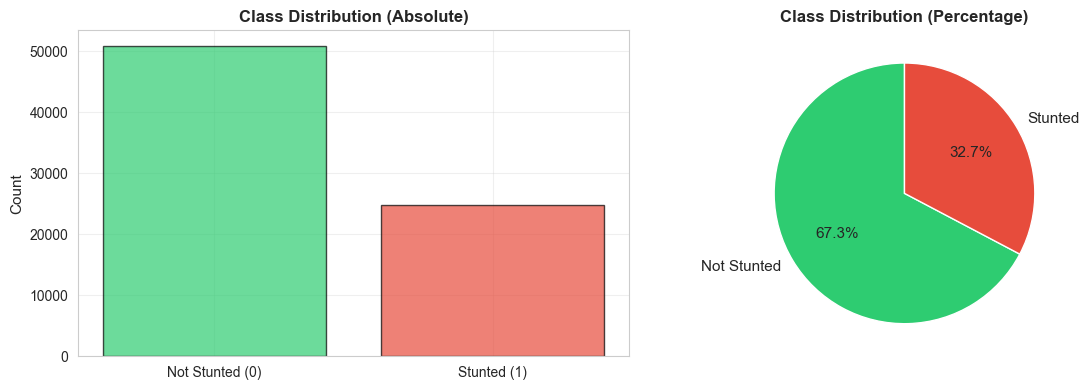


Class Imbalance:
  Not Stunted: 50,859 (67.3%)
  Stunted: 24,734 (32.7%)
  Ratio (neg/pos): 2.06


In [45]:
# ── CLASS DISTRIBUTION ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
class_counts = y.value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.bar(['Not Stunted (0)', 'Stunted (1)'], class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Class Distribution (Absolute)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Percentage plot
percentages = (class_counts.values / len(y) * 100)
ax2.pie(percentages, labels=['Not Stunted', 'Stunted'], autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '01_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass Imbalance:")
print(f"  Not Stunted: {class_counts[0]:,} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"  Stunted: {class_counts[1]:,} ({class_counts[1]/len(y)*100:.1f}%)")
print(f"  Ratio (neg/pos): {class_counts[0]/class_counts[1]:.2f}")

---
## STEP 2: FEATURE ENGINEERING & PREPROCESSING

In [46]:
# ── FEATURE ENGINEERING ─────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("Feature Engineering...")
print(f"{'='*55}")

X_eng = engineer_features(X)
new_features = X_eng.shape[1] - X.shape[1]

print(f"✓ Features after engineering: {X_eng.shape[1]} (+{new_features} new)")
print(f"\nNew engineered features:")
new_feat_list = [
    "age_sq", "age_x_poverty", "age_x_low_edu", "mother_risk", "env_risk",
    "mother_short", "birth_risk", "short_interval",
    "mother_age_x_birth_risk", "mother_short_x_low_bw", "low_edu_x_antenatal",
    "low_bmi_x_short_interval", "maternal_x_birth_risk", "delivery_x_antenatal",
    "wealth_x_birth_risk"
]
for feat in new_feat_list:
    if feat in X_eng.columns:
        print(f"  • {feat}")


Feature Engineering...
✓ Features after engineering: 35 (+15 new)

New engineered features:
  • age_sq
  • age_x_poverty
  • age_x_low_edu
  • mother_risk
  • env_risk
  • mother_short
  • birth_risk
  • short_interval
  • mother_age_x_birth_risk
  • mother_short_x_low_bw
  • low_edu_x_antenatal
  • low_bmi_x_short_interval
  • maternal_x_birth_risk
  • delivery_x_antenatal
  • wealth_x_birth_risk


In [47]:
# -- TRAIN / VALIDATION / TEST SPLIT -----------------------------------------
print(f"\n{'='*60}")
print('Train / Validation / Test Split  (70 / 15 / 15  stratified)')
print(f"{'='*60}")

# Step 1: 70% train, 30% temp
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_eng, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

# Step 2: split temp 50/50 -> 15% validation + 15% test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

n_total = len(X_eng)
print(f'Training   set : {len(X_train_raw):,} rows ({len(X_train_raw)/n_total*100:.0f}%)')
print(f'  Stunted: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'\nValidation set : {len(X_val_raw):,} rows ({len(X_val_raw)/n_total*100:.0f}%)')
print(f'  Stunted: {y_val.sum():,} ({y_val.mean()*100:.1f}%)')
print(f'\nTest       set : {len(X_test_raw):,} rows ({len(X_test_raw)/n_total*100:.0f}%)')
print(f'  Stunted: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print('\nClass distribution preserved across all three splits (stratify=y)')



Train / Validation / Test Split  (70 / 15 / 15  stratified)
Training   set : 52,915 rows (70%)
  Stunted: 17,314 (32.7%)

Validation set : 11,339 rows (15%)
  Stunted: 3,710 (32.7%)

Test       set : 11,339 rows (15%)
  Stunted: 3,710 (32.7%)

Class distribution preserved across all three splits (stratify=y)


In [48]:
# -- FIT ENCODER ON TRAINING SET ONLY ----------------------------------------
print(f"\n{'='*55}")
print('Encoding Categorical Features -> One-Hot')
print(f"{'='*55}")

encoder = fit_encoder(X_train_raw)
X_train = apply_encoding(X_train_raw, encoder)
X_val   = apply_encoding(X_val_raw,   encoder)   # encoded with train-fit encoder
X_test  = apply_encoding(X_test_raw,  encoder)   # encoded with train-fit encoder

ohe_cols = encoder.get_feature_names_out(CAT_COLS).tolist()
print(f'One-hot columns added : {len(ohe_cols)}')
print(f'  Region categories  : {[c for c in ohe_cols if "region" in c][:3]}...')
print(f'  Country categories : {[c for c in ohe_cols if "country" in c]}')
print(f'\nFinal feature count : {X_train.shape[1]}')
print(f'  X_train {X_train.shape}  |  X_val {X_val.shape}  |  X_test {X_test.shape}')



Encoding Categorical Features -> One-Hot
One-hot columns added : 63
  Region categories  : ['region_0.0', 'region_1.0', 'region_2.0']...
  Country categories : ['country_1', 'country_2', 'country_3', 'country_4', 'country_5', 'country_6', 'country_7', 'country_8', 'country_9', 'country_10']

Final feature count : 96
  X_train (52915, 96)  |  X_val (11339, 96)  |  X_test (11339, 96)


In [49]:
# ── CLASS WEIGHTS FOR IMBALANCED DATA ───────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"\nClass Imbalance Adjustment:")
print(f"  Negative (not stunted): {neg:,}")
print(f"  Positive (stunted): {pos:,}")
print(f"  Scale pos weight (neg/pos): {scale_pos_weight:.2f}")
print(f"  → XGBoost will weight positive class {scale_pos_weight:.2f}x more")


Class Imbalance Adjustment:
  Negative (not stunted): 35,601
  Positive (stunted): 17,314
  Scale pos weight (neg/pos): 2.06
  → XGBoost will weight positive class 2.06x more


---
## STEP 3: BASELINE MODELS
Train Logistic Regression and Random Forest for comparison

In [50]:
print(f"\n{'='*55}")
print("Training Baseline Models...")
print(f"{'='*55}")

baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED,
            class_weight='balanced'
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
}

baseline_results = []
for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    cv = cross_val_score(
        model, X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
        scoring='roc_auc', n_jobs=-1
    )
    print(f"  CV ROC-AUC: {cv.mean():.3f} ± {cv.std():.3f}")
    result = evaluate(name, model, X_test, y_test)
    baseline_results.append(result)


Training Baseline Models...

Training Logistic Regression...
  CV ROC-AUC: 0.762 ± 0.003

  Logistic Regression  (threshold=0.500)
    Recall:    0.720  (target >= 0.75)
    Precision: 0.532
    F1 Score:  0.611
    F2 Score:  0.672
    ROC-AUC:   0.771

Training Random Forest...
  CV ROC-AUC: 0.761 ± 0.002

  Random Forest  (threshold=0.500)
    Recall:    0.698  (target >= 0.75)
    Precision: 0.534
    F1 Score:  0.605
    F2 Score:  0.658
    ROC-AUC:   0.766


---
## STEP 4: XGBOOST — TWO-STAGE TUNING
*(Part of Experiment 1 — MAIN)*

#### Stage 1: Quick Screening (n_iter=15, all weight values)
Rapidly identify the best `scale_pos_weight` candidates — scoring: **F1**

In [51]:
print(f"\n{'='*55}")
print("STAGE 1: Quick Screening (n_iter=15, all weights)...")
print(f"Default ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"{'='*55}")

test_weights = [1.5, 2.0, scale_pos_weight, 2.5]
stage1_results = {}

param_dist = {
    'n_estimators':     randint(200, 600),
    'max_depth':        randint(4, 9),
    'learning_rate':    uniform(0.01, 0.14),
    'subsample':        uniform(0.65, 0.35),
    'colsample_bytree': uniform(0.65, 0.35),
    'min_child_weight': randint(3, 15),
    'gamma':            uniform(0, 0.3),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(0.5, 1.5),
}

print(f"\n{'Weight':<8} {'CV F1':>8}")
print("-" * 25)

for weight in test_weights:
    base_xgb = xgb.XGBClassifier(
        scale_pos_weight=weight,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        n_jobs=-1, verbosity=0,
    )
    search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_dist,
        n_iter=15, scoring='f1',
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0, refit=True,
    )
    search.fit(X_train, y_train)
    stage1_results[weight] = {'cv_f1': search.best_score_, 'params': search.best_params_}
    print(f"{weight:<8.2f} {search.best_score_:>8.3f}")

top_weights     = sorted(stage1_results.items(), key=lambda x: x[1]['cv_f1'], reverse=True)[:2]
top_weight_list = [w[0] for w in top_weights]
print(f"\n\u2713 Top 2 weights selected: {[f'{w:.2f}' for w in top_weight_list]}")


STAGE 1: Quick Screening (n_iter=15, all weights)...
Default ratio (neg/pos): 2.06

Weight      CV F1
-------------------------
1.50        0.593
2.00        0.607
2.06        0.608
2.50        0.609

✓ Top 2 weights selected: ['2.50', '2.06']


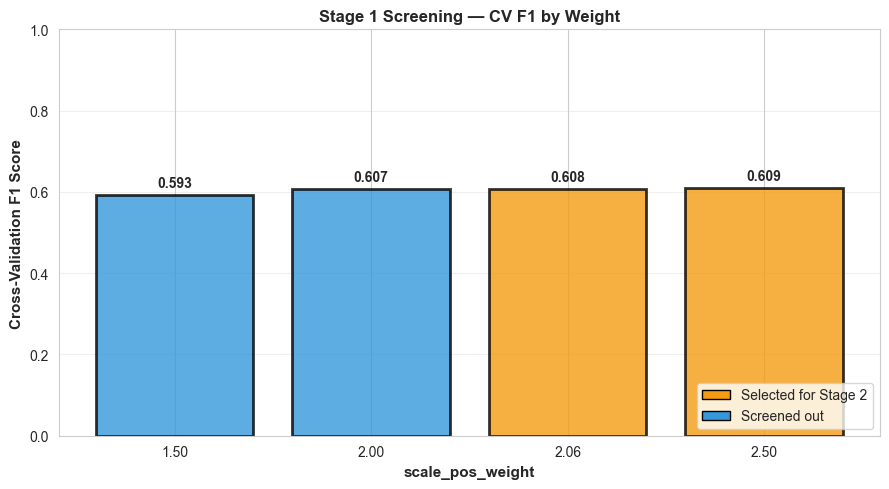

In [52]:
# Visualize Stage 1 results
fig, ax = plt.subplots(figsize=(9, 5))

weights_sorted = sorted(stage1_results.items(), key=lambda x: x[0])
weights  = [w[0] for w in weights_sorted]
cv_f1s   = [w[1]['cv_f1'] for w in weights_sorted]
colors   = ['#f39c12' if w in top_weight_list else '#3498db' for w in weights]

ax.bar([f'{w:.2f}' for w in weights], cv_f1s, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Cross-Validation F1 Score', fontsize=11, fontweight='bold')
ax.set_xlabel('scale_pos_weight', fontsize=11, fontweight='bold')
ax.set_title('Stage 1 Screening — CV F1 by Weight', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1]); ax.grid(alpha=0.3, axis='y')
for i, (w, f1) in enumerate(zip(weights, cv_f1s)):
    ax.text(i, f1 + 0.02, f'{f1:.3f}', ha='center', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#f39c12', edgecolor='black', label='Selected for Stage 2'),
    Patch(facecolor='#3498db', edgecolor='black', label='Screened out'),
], loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '02_stage1_screening.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Stage 2: Full Tuning (n_iter=30, top 2 weights)
Thoroughly tune the best 2 weight values with **30 iterations** each — scoring: **F1**

In [53]:
print(f"\n{'='*55}")
print('STAGE 2: Full Tuning (n_iter=30, top 2 weights)...')
print(f"{'='*55}")

xgb_results_by_weight = {}
xgb_default_by_weight = {}   # default-threshold results -> used in Experiment 2

for weight in top_weight_list:
    print(f'\n--- Full tuning: scale_pos_weight = {weight:.2f} ---')

    base_xgb = xgb.XGBClassifier(
        scale_pos_weight=weight,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        n_jobs=-1, verbosity=0,
    )
    search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_dist,
        n_iter=30, scoring='f1',
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0, refit=True,
    )
    search.fit(X_train, y_train)

    tuned_xgb   = search.best_estimator_
    best_params = search.best_params_
    print(f'  Best CV F1: {search.best_score_:.3f}')

    # -- Default threshold on test (kept for Experiment 2 comparison only) ----
    xgb_default = evaluate(
        f'XGBoost (weight={weight:.2f}, threshold=0.500)',
        tuned_xgb, X_test, y_test, threshold=0.5
    )
    xgb_default_by_weight[weight] = xgb_default

    # -- Threshold selection on VALIDATION SET (no leakage) -------------------
    y_val_proba = tuned_xgb.predict_proba(X_val)[:, 1]

    thr_f2  = find_f2_threshold(y_val.values, y_val_proba)
    thr_f1r = find_optimal_threshold(y_val.values, y_val_proba, min_recall=RECALL_TARGET)

    m_f2  = threshold_metrics(y_val.values, y_val_proba, thr_f2)
    m_f1r = threshold_metrics(y_val.values, y_val_proba, thr_f1r)

    print(f'\n  Threshold candidates evaluated on VALIDATION set:')
    print(f"  {'Criterion':<28} {'Thr':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'F2':>7}")
    print('  ' + '-' * 62)
    print(f"  {'F2-optimal':<28} {m_f2['threshold']:>6.3f} {m_f2['precision']:>7.3f}"
          f" {m_f2['recall']:>7.3f} {m_f2['f1']:>7.3f} {m_f2['f2']:>7.3f}")
    print(f"  {'Max F1 (Recall >= 0.75)':<28} {m_f1r['threshold']:>6.3f} {m_f1r['precision']:>7.3f}"
          f" {m_f1r['recall']:>7.3f} {m_f1r['f1']:>7.3f} {m_f1r['f2']:>7.3f}")

    # Prefer F2-optimal if it meets min-recall, else fall back to F1-recall
    if m_f2['recall'] >= RECALL_TARGET:
        opt_thr          = thr_f2
        chosen_criterion = 'F2-optimal'
    else:
        opt_thr          = thr_f1r
        chosen_criterion = 'Max F1 (Recall >= 0.75)'

    print(f'\n  -> Selected: {chosen_criterion}  (threshold = {opt_thr:.3f})')

    # -- Apply chosen threshold to TEST SET once -- final evaluation -----------
    xgb_optimal = evaluate(
        f'XGBoost (weight={weight:.2f}, threshold={opt_thr:.3f})',
        tuned_xgb, X_test, y_test, threshold=opt_thr
    )
    xgb_results_by_weight[weight] = {
        'model':           tuned_xgb,
        'threshold':       opt_thr,
        'criterion':       chosen_criterion,
        'params':          best_params,
        'result_default':  xgb_default,
        'results':         xgb_optimal,
        'val_metrics_f2':  m_f2,
        'val_metrics_f1r': m_f1r,
    }



STAGE 2: Full Tuning (n_iter=30, top 2 weights)...

--- Full tuning: scale_pos_weight = 2.50 ---
  Best CV F1: 0.610

  XGBoost (weight=2.50, threshold=0.500)  (threshold=0.500)
    Recall:    0.760  (target >= 0.75)
    Precision: 0.515
    F1 Score:  0.614
    F2 Score:  0.694
    ROC-AUC:   0.773

  Threshold candidates evaluated on VALIDATION set:
  Criterion                       Thr    Prec  Recall      F1      F2
  --------------------------------------------------------------
  F2-optimal                    0.321   0.427   0.912   0.582   0.743
  Max F1 (Recall >= 0.75)       0.512   0.519   0.750   0.614   0.689

  -> Selected: F2-optimal  (threshold = 0.321)

  XGBoost (weight=2.50, threshold=0.321)  (threshold=0.321)
    Recall:    0.899  (target >= 0.75)
    Precision: 0.426
    F1 Score:  0.578
    F2 Score:  0.735
    ROC-AUC:   0.773

--- Full tuning: scale_pos_weight = 2.06 ---
  Best CV F1: 0.609

  XGBoost (weight=2.06, threshold=0.500)  (threshold=0.500)
    Recall:

In [54]:
# Stage 2 Results: threshold candidates (VAL) + test evaluation
print(f"\n{'='*80}")
print('Stage 2 -- Threshold Selection (VAL) and Test Evaluation')
print(f"{'='*80}")

for weight in sorted(xgb_results_by_weight):
    entry = xgb_results_by_weight[weight]
    r_def = xgb_default_by_weight[weight]
    r_opt = entry['results']
    thr   = entry['threshold']
    crit  = entry['criterion']
    mf2   = entry['val_metrics_f2']
    mf1r  = entry['val_metrics_f1r']

    print(f'\n  weight={weight:.2f}  |  Selected: {crit}  |  Chosen threshold: {thr:.3f}')
    print(f"  {'Source':<6} {'Criterion':<26} {'Thr':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'F2':>7} {'AUC':>8}")
    print('  ' + '-' * 75)
    print(f"  {'VAL':<6} {'F2-optimal':<26} {mf2['threshold']:>6.3f}"
          f" {mf2['precision']:>7.3f} {mf2['recall']:>7.3f} {mf2['f1']:>7.3f} {mf2['f2']:>7.3f} {'--':>8}")
    print(f"  {'VAL':<6} {'Max F1 (Recall>=0.75)':<26} {mf1r['threshold']:>6.3f}"
          f" {mf1r['precision']:>7.3f} {mf1r['recall']:>7.3f} {mf1r['f1']:>7.3f} {mf1r['f2']:>7.3f} {'--':>8}")
    print(f"  {'TEST':<6} {'Default (0.500)':<26} {'0.500':>6}"
          f" {r_def['precision']:>7.3f} {r_def['recall']:>7.3f} {r_def['f1']:>7.3f} {r_def['f2']:>7.3f} {r_def['roc_auc']:>8.3f}")
    print(f"  {'TEST':<6} {('Chosen* '+crit[:18]):<26} {thr:>6.3f}"
          f" {r_opt['precision']:>7.3f} {r_opt['recall']:>7.3f} {r_opt['f1']:>7.3f} {r_opt['f2']:>7.3f} {r_opt['roc_auc']:>8.3f}")

print('\n  * threshold selected on VAL, applied to TEST once -- no revisiting')

# Select best model by F1 on test
best_entry        = max(xgb_results_by_weight.items(), key=lambda x: x[1]['results']['f1'])
best_weight       = best_entry[0]
best_result       = best_entry[1]
tuned_xgb         = best_result['model']
optimal_threshold = best_result['threshold']
best_params       = best_result['params']
best              = best_result['results']               # final optimal-threshold result
best_default      = xgb_default_by_weight[best_weight]  # default-threshold (Experiment 2)
explainer         = shap.TreeExplainer(tuned_xgb)

print(f'\nBest model: weight={best_weight:.2f}  threshold={optimal_threshold:.3f}'
      f'  [{best_result["criterion"]}]')
print(f'  Recall={best["recall"]:.3f}  Precision={best["precision"]:.3f}'
      f'  F1={best["f1"]:.3f}  F2={best["f2"]:.3f}  ROC-AUC={best["roc_auc"]:.3f}')



Stage 2 -- Threshold Selection (VAL) and Test Evaluation

  weight=2.06  |  Selected: F2-optimal  |  Chosen threshold: 0.270
  Source Criterion                     Thr    Prec  Recall      F1      F2      AUC
  ---------------------------------------------------------------------------
  VAL    F2-optimal                  0.270   0.421   0.925   0.579   0.746       --
  VAL    Max F1 (Recall>=0.75)       0.467   0.525   0.753   0.619   0.693       --
  TEST   Default (0.500)             0.500   0.543   0.716   0.617   0.673    0.777
  TEST   Chosen* F2-optimal          0.270   0.420   0.913   0.575   0.739    0.777

  weight=2.50  |  Selected: F2-optimal  |  Chosen threshold: 0.321
  Source Criterion                     Thr    Prec  Recall      F1      F2      AUC
  ---------------------------------------------------------------------------
  VAL    F2-optimal                  0.321   0.427   0.912   0.582   0.743       --
  VAL    Max F1 (Recall>=0.75)       0.512   0.519   0.750   0

---
## EXPERIMENT 1 — SUMMARY: Baseline → Tuned → Threshold

Full model progression from simple baselines to tuned XGBoost with optimal threshold.
**Scoring criterion throughout: F1**


EXPERIMENT 1 — Model Progression Table
  Stage      Model                                          Recall    Prec      F1      AUC
  -----------------------------------------------------------------------------------
  1 (LR)     Logistic Regression                             0.720   0.532   0.611    0.771
  1 (RF)     Random Forest                                   0.698   0.534   0.605    0.766
  2 (XGB)    XGBoost (weight=2.50, threshold=0.500)          0.760   0.515   0.614    0.773
  3 (XGB+T)  XGBoost (weight=2.50, threshold=0.321)          0.899   0.426   0.578    0.773  <- FINAL

  Delta gain (Logistic Regression -> Final XGB):
    Recall     0.720 -> 0.899  (+0.180)
    F1         0.611 -> 0.578  (-0.034)
    ROC-AUC    0.771 -> 0.773  (+0.003)


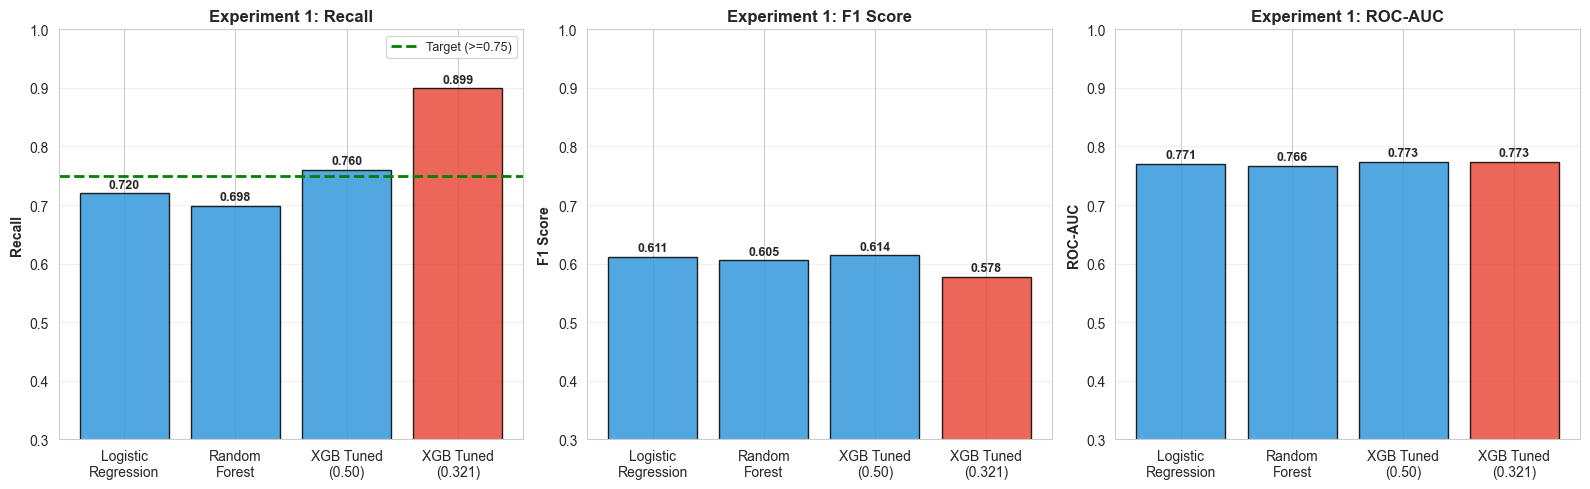

✓ Experiment 1 chart saved


In [55]:
# Experiment 1: Model Progression Table + Plot
exp1_results = baseline_results + [best_default, best]
all_results  = exp1_results    # used by downstream STEP 6 cells

print(f"\n{'='*85}")
print("EXPERIMENT 1 — Model Progression Table")
print(f"{'='*85}")
print(f"  {'Stage':<10} {'Model':<45} {'Recall':>7} {'Prec':>7} {'F1':>7} {'AUC':>8}")
print("  " + "-" * 83)
stages = ['1 (LR)', '1 (RF)', '2 (XGB)', '3 (XGB+T)']
for stage, r in zip(stages, exp1_results):
    mark = "  <- FINAL" if r['name'] == best['name'] else ""
    print(f"  {stage:<10} {r['name']:<45} {r['recall']:>7.3f} {r['precision']:>7.3f} {r['f1']:>7.3f} {r['roc_auc']:>8.3f}{mark}")

lr_r = baseline_results[0]
print(f"\n  Delta gain (Logistic Regression -> Final XGB):")
for lbl, k in [('Recall', 'recall'), ('F1', 'f1'), ('ROC-AUC', 'roc_auc')]:
    print(f"    {lbl:<10} {lr_r[k]:.3f} -> {best[k]:.3f}  ({best[k]-lr_r[k]:+.3f})")

# Bar chart
short_names = [
    'Logistic\nRegression', 'Random\nForest',
    'XGB Tuned\n(0.50)', f'XGB Tuned\n({optimal_threshold:.3f})'
]
best_idx = len(exp1_results) - 1
clrs     = ['#e74c3c' if i == best_idx else '#3498db' for i in range(len(exp1_results))]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, title, target in zip(
    axes,
    ['recall', 'f1', 'roc_auc'],
    ['Recall', 'F1 Score', 'ROC-AUC'],
    [RECALL_TARGET, None, None]
):
    vals = [r[key] for r in exp1_results]
    bars = ax.bar(short_names, vals, color=clrs, alpha=0.85, edgecolor='black')
    if target:
        ax.axhline(target, color='green', linestyle='--', lw=2, label=f'Target (>={target})')
        ax.legend(fontsize=9)
    ax.set_title(f'Experiment 1: {title}', fontweight='bold', fontsize=12)
    ax.set_ylabel(title, fontweight='bold')
    ax.set_ylim([0.3, 1.0]); ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '03_exp1_model_progression.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Experiment 1 chart saved")

---
## EXPERIMENT 2 — Threshold Comparison: 0.50 vs Optimal

Quantify the gain from threshold optimisation on the best-tuned XGBoost.
Optimal threshold = highest F1 that still satisfies Recall >= RECALL_TARGET.

In [56]:
# Experiment 2: Threshold Comparison Table
from sklearn.metrics import confusion_matrix as _cm

print(f"\n{'='*70}")
print("EXPERIMENT 2 — Threshold Comparison")
print(f"{'='*70}")
print(f"Model: XGBoost  (scale_pos_weight={best_weight:.2f})\n")

print(f"{'Metric':<15} {'Default (0.50)':>15} {'Optimal ({:.3f})'.format(optimal_threshold):>20} {'Delta':>8}")
print("-" * 62)
for lbl, k in [('Recall', 'recall'), ('Precision', 'precision'), ('F1', 'f1'), ('ROC-AUC', 'roc_auc')]:
    vd, vo = best_default[k], best[k]
    delta  = vo - vd
    print(f"{lbl:<15} {vd:>15.3f} {vo:>20.3f} {('+' if delta>=0 else '')+f'{delta:.3f}':>8}")

cm_def = _cm(y_test, best_default['y_pred'])
cm_opt = _cm(y_test, best['y_pred'])

print(f"\n  Confusion Matrix (Default -> Optimal):")
print(f"  {'Label':<32} {'Default':>9} {'Optimal':>9} {'Delta':>6}")
print("  " + "-" * 60)
for lbl, d, o in zip(
    ['TN - correct not-stunted', 'FP - false alarm', 'FN - missed stunted (want low)', 'TP - caught stunted (want high)'],
    cm_def.ravel(), cm_opt.ravel()
):
    d, o = int(d), int(o)
    print(f"  {lbl:<32} {d:>9,} {o:>9,} {('+' if o-d>=0 else '')+str(o-d):>6}")


EXPERIMENT 2 — Threshold Comparison
Model: XGBoost  (scale_pos_weight=2.50)

Metric           Default (0.50)      Optimal (0.321)    Delta
--------------------------------------------------------------
Recall                    0.760                0.899   +0.139
Precision                 0.515                0.426   -0.089
F1                        0.614                0.578   -0.036
ROC-AUC                   0.773                0.773   +0.000

  Confusion Matrix (Default -> Optimal):
  Label                              Default   Optimal  Delta
  ------------------------------------------------------------
  TN - correct not-stunted             4,968     3,125  -1843
  FP - false alarm                     2,661     4,504  +1843
  FN - missed stunted (want low)         889       374   -515
  TP - caught stunted (want high)      2,821     3,336   +515


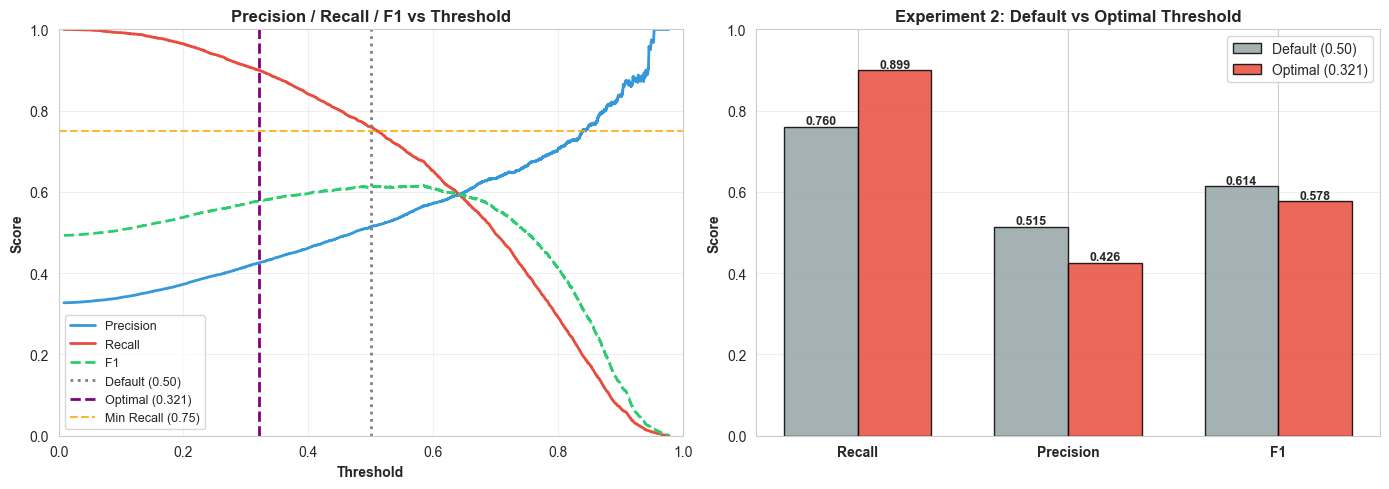

✓ Experiment 2 chart saved


In [57]:
# Experiment 2: Precision/Recall/F1 vs Threshold + bar comparison
y_proba_best = best['y_proba']
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, y_proba_best)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thr_arr, prec_arr[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(thr_arr, rec_arr[:-1],  label='Recall',    color='#e74c3c', lw=2)
ax.plot(thr_arr, f1_arr,        label='F1',        color='#2ecc71', lw=2, linestyle='--')
ax.axvline(0.5,               color='gray',   linestyle=':',  lw=2, label='Default (0.50)')
ax.axvline(optimal_threshold, color='purple', linestyle='--', lw=2, label=f'Optimal ({optimal_threshold:.3f})')
ax.axhline(RECALL_TARGET,     color='orange', linestyle='--', lw=1.5, alpha=0.8, label=f'Min Recall ({RECALL_TARGET})')
ax.set_xlabel('Threshold', fontweight='bold'); ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1])

ax = axes[1]
mets = ['Recall', 'Precision', 'F1']
dv   = [best_default['recall'], best_default['precision'], best_default['f1']]
ov   = [best['recall'],         best['precision'],         best['f1']]
x = np.arange(len(mets)); w = 0.35
b1 = ax.bar(x-w/2, dv, w, label='Default (0.50)',                     color='#95a5a6', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, ov, w, label=f'Optimal ({optimal_threshold:.3f})', color='#e74c3c', alpha=0.85, edgecolor='black')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(mets, fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Experiment 2: Default vs Optimal Threshold', fontweight='bold', fontsize=12)
ax.legend(); ax.set_ylim([0,1]); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '07_exp2_threshold_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Experiment 2 chart saved")

---
## EXPERIMENT 3 — Feature Engineering Impact

Quantify the value of interaction/composite features.
**Same hyperparameters** as the best model — no new search, no extra compute.

In [58]:
# Experiment 3: Feature Engineering Impact
print(f"\n{'='*65}")
print('EXPERIMENT 3 -- Feature Engineering Impact')
print(f"{'='*65}")

# Same split indices, raw features only (no engineer_features)
_enc_noeng    = fit_encoder(X.loc[X_train_raw.index])
X_train_noeng = apply_encoding(X.loc[X_train_raw.index], _enc_noeng)
X_val_noeng   = apply_encoding(X.loc[X_val_raw.index],   _enc_noeng)  # for threshold selection
X_test_noeng  = apply_encoding(X.loc[X_test_raw.index],  _enc_noeng)

print(f'  Raw features:        {X_train_noeng.shape[1]}')
print(f'  Engineered features: {X_train.shape[1]}')
print(f'  Added features:      +{X_train.shape[1] - X_train_noeng.shape[1]}')
print(f'\n  Training XGB with best params (no new search)...')

xgb_noeng = xgb.XGBClassifier(
    scale_pos_weight=best_weight,
    eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
    **best_params
)
xgb_noeng.fit(X_train_noeng, y_train)

# Default threshold on test
r_noeng_def = evaluate('XGB No-Engineering (0.500)',
                        xgb_noeng, X_test_noeng, y_test, threshold=0.5)

# Threshold selected on VALIDATION SET -- no leakage
y_val_proba_noeng = xgb_noeng.predict_proba(X_val_noeng)[:, 1]
thr_noeng         = find_optimal_threshold(
    y_val.values, y_val_proba_noeng, min_recall=RECALL_TARGET
)

r_noeng_opt = evaluate(f'XGB No-Engineering ({thr_noeng:.3f})',
                        xgb_noeng, X_test_noeng, y_test, threshold=thr_noeng)

print(f"\n{'='*80}")
print('EXPERIMENT 3 -- Results Table')
print(f"{'='*80}")
print(f"  {'Configuration':<44} {'Recall':>7} {'Prec':>7} {'F1':>7} {'AUC':>8}")
print('  ' + '-' * 78)
for lbl, r in [
    ('No Engineering  (threshold=0.500)',                                  r_noeng_def),
    (f'No Engineering  (threshold={thr_noeng:.3f})',                       r_noeng_opt),
    ('With Engineering (threshold=0.500)',                                 best_default),
    (f'With Engineering (threshold={optimal_threshold:.3f})  <- FINAL',   best),
]:
    print(f"  {lbl:<44} {r['recall']:>7.3f} {r['precision']:>7.3f} {r['f1']:>7.3f} {r['roc_auc']:>8.3f}")

print(f'\n  Delta Engineering gain (val-selected threshold):')
for lbl, k in [('Recall', 'recall'), ('F1', 'f1'), ('ROC-AUC', 'roc_auc')]:
    print(f'    {lbl:<10} {r_noeng_opt[k]:.3f} -> {best[k]:.3f}  ({best[k]-r_noeng_opt[k]:+.3f})')



EXPERIMENT 3 -- Feature Engineering Impact
  Raw features:        81
  Engineered features: 96
  Added features:      +15

  Training XGB with best params (no new search)...

  XGB No-Engineering (0.500)  (threshold=0.500)
    Recall:    0.765  (target >= 0.75)
    Precision: 0.514
    F1 Score:  0.615
    F2 Score:  0.697
    ROC-AUC:   0.775

  XGB No-Engineering (0.507)  (threshold=0.507)
    Recall:    0.758  (target >= 0.75)
    Precision: 0.517
    F1 Score:  0.615
    F2 Score:  0.694
    ROC-AUC:   0.775

EXPERIMENT 3 -- Results Table
  Configuration                                 Recall    Prec      F1      AUC
  ------------------------------------------------------------------------------
  No Engineering  (threshold=0.500)              0.765   0.514   0.615    0.775
  No Engineering  (threshold=0.507)              0.758   0.517   0.615    0.775
  With Engineering (threshold=0.500)             0.760   0.515   0.614    0.773
  With Engineering (threshold=0.321)  <- FINAL   

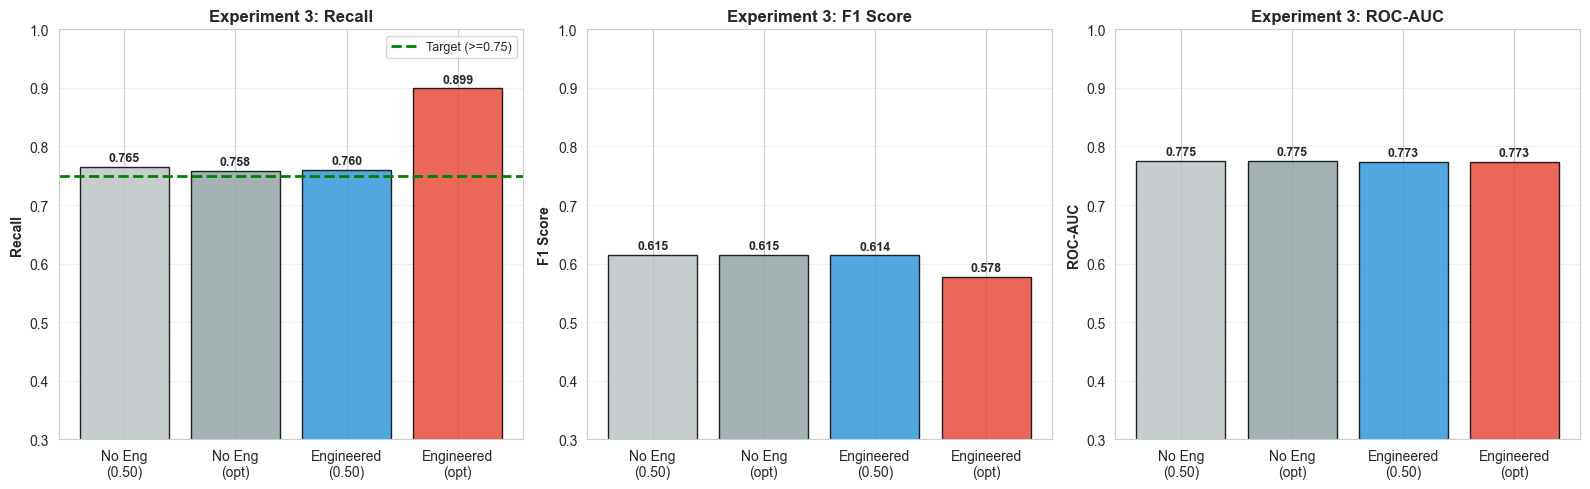

✓ Experiment 3 chart saved


In [59]:
# Experiment 3: Visualization
exp3_configs = [
    ('No Eng\n(0.50)',             r_noeng_def),
    (f'No Eng\n(opt)',             r_noeng_opt),
    ('Engineered\n(0.50)',         best_default),
    (f'Engineered\n(opt)',         best),
]
lbls = [c[0] for c in exp3_configs]
clrs = ['#bdc3c7', '#95a5a6', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, title in zip(axes, ['recall', 'f1', 'roc_auc'], ['Recall', 'F1 Score', 'ROC-AUC']):
    vals = [r[key] for _, r in exp3_configs]
    bars = ax.bar(lbls, vals, color=clrs, alpha=0.85, edgecolor='black')
    if key == 'recall':
        ax.axhline(RECALL_TARGET, color='green', linestyle='--', lw=2, label=f'Target (>={RECALL_TARGET})')
        ax.legend(fontsize=9)
    ax.set_title(f'Experiment 3: {title}', fontweight='bold', fontsize=12)
    ax.set_ylabel(title, fontweight='bold')
    ax.set_ylim([0.3, 1.0]); ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '08_exp3_feature_engineering.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Experiment 3 chart saved")

---
## ALL EXPERIMENTS — SUMMARY

Three experiments validate the modeling approach for health-critical stunting prediction.

In [60]:
# All Experiments Summary
print(f"\n{'='*85}")
print("  ALL EXPERIMENTS — KEY FINDINGS")
print(f"{'='*85}")

lr_r = baseline_results[0]; rf_r = baseline_results[1]

print(f"\n\u2714 EXPERIMENT 1 — Baseline -> Tuned -> Threshold  (scoring: F1)")
print(f"   Logistic Regression:              Recall={lr_r['recall']:.3f}  F1={lr_r['f1']:.3f}  AUC={lr_r['roc_auc']:.3f}")
print(f"   Random Forest:                    Recall={rf_r['recall']:.3f}  F1={rf_r['f1']:.3f}  AUC={rf_r['roc_auc']:.3f}")
print(f"   XGB Tuned (0.50):                 Recall={best_default['recall']:.3f}  F1={best_default['f1']:.3f}  AUC={best_default['roc_auc']:.3f}")
print(f"   XGB Tuned ({optimal_threshold:.3f}) <- FINAL:  Recall={best['recall']:.3f}  F1={best['f1']:.3f}  AUC={best['roc_auc']:.3f}")

print(f"\n\u2714 EXPERIMENT 2 — Threshold Comparison: 0.50 vs {optimal_threshold:.3f}")
print(f"   Default (0.50):   Recall={best_default['recall']:.3f}  Prec={best_default['precision']:.3f}  F1={best_default['f1']:.3f}")
print(f"   Optimal ({optimal_threshold:.3f}): Recall={best['recall']:.3f}  Prec={best['precision']:.3f}  F1={best['f1']:.3f}")
print(f"   Delta: Recall {best['recall']-best_default['recall']:+.3f}   Precision {best['precision']-best_default['precision']:+.3f}   F1 {best['f1']-best_default['f1']:+.3f}")

print(f"\n\u2714 EXPERIMENT 3 — Feature Engineering (+{X_train.shape[1] - X_train_noeng.shape[1]} features)")
print(f"   No Engineering (opt):  Recall={r_noeng_opt['recall']:.3f}  F1={r_noeng_opt['f1']:.3f}  AUC={r_noeng_opt['roc_auc']:.3f}")
print(f"   Engineered (opt):      Recall={best['recall']:.3f}  F1={best['f1']:.3f}  AUC={best['roc_auc']:.3f}")
print(f"   Delta: Recall {best['recall']-r_noeng_opt['recall']:+.3f}   F1 {best['f1']-r_noeng_opt['f1']:+.3f}   AUC {best['roc_auc']-r_noeng_opt['roc_auc']:+.3f}")

print(f"\n{'='*85}")
print(f"  FINAL MODEL: Tuned XGBoost + Feature Engineering + Threshold = {optimal_threshold:.3f}")
print(f"  Recall={best['recall']:.3f}  Precision={best['precision']:.3f}  F1={best['f1']:.3f}  ROC-AUC={best['roc_auc']:.3f}")
print(f"{'='*85}")


  ALL EXPERIMENTS — KEY FINDINGS

✔ EXPERIMENT 1 — Baseline -> Tuned -> Threshold  (scoring: F1)
   Logistic Regression:              Recall=0.720  F1=0.611  AUC=0.771
   Random Forest:                    Recall=0.698  F1=0.605  AUC=0.766
   XGB Tuned (0.50):                 Recall=0.760  F1=0.614  AUC=0.773
   XGB Tuned (0.321) <- FINAL:  Recall=0.899  F1=0.578  AUC=0.773

✔ EXPERIMENT 2 — Threshold Comparison: 0.50 vs 0.321
   Default (0.50):   Recall=0.760  Prec=0.515  F1=0.614
   Optimal (0.321): Recall=0.899  Prec=0.426  F1=0.578
   Delta: Recall +0.139   Precision -0.089   F1 -0.036

✔ EXPERIMENT 3 — Feature Engineering (+15 features)
   No Engineering (opt):  Recall=0.758  F1=0.615  AUC=0.775
   Engineered (opt):      Recall=0.899  F1=0.578  AUC=0.773
   Delta: Recall +0.141   F1 -0.037   AUC -0.002

  FINAL MODEL: Tuned XGBoost + Feature Engineering + Threshold = 0.321
  Recall=0.899  Precision=0.426  F1=0.578  ROC-AUC=0.773


---
## STEP 6: DETAILED PERFORMANCE ANALYSIS
Confusion Matrix, ROC Curve, and Precision-Recall Curve of the Final Model

In [61]:
# Detailed Report: classification report + confusion matrix
print(f"\nDetailed Report - {best['name']}:")
print(classification_report(y_test, best['y_pred'], target_names=['Not Stunted', 'Stunted']))

cm = confusion_matrix(y_test, best['y_pred'])
print(f"Confusion Matrix:")
print(f"  TN  (correct not-stunted): {cm[0,0]:,}")
print(f"  FP  (false alarm):          {cm[0,1]:,}")
print(f"  FN  (missed stunted):       {cm[1,0]:,}")
print(f"  TP  (caught stunted):       {cm[1,1]:,}")

fn_rate = cm[1,0] / (cm[1,0] + cm[1,1])
print(f"  Miss rate: {fn_rate*100:.1f}%")


Detailed Report - XGBoost (weight=2.50, threshold=0.321):
              precision    recall  f1-score   support

 Not Stunted       0.89      0.41      0.56      7629
     Stunted       0.43      0.90      0.58      3710

    accuracy                           0.57     11339
   macro avg       0.66      0.65      0.57     11339
weighted avg       0.74      0.57      0.57     11339

Confusion Matrix:
  TN  (correct not-stunted): 3,125
  FP  (false alarm):          4,504
  FN  (missed stunted):       374
  TP  (caught stunted):       3,336
  Miss rate: 10.1%


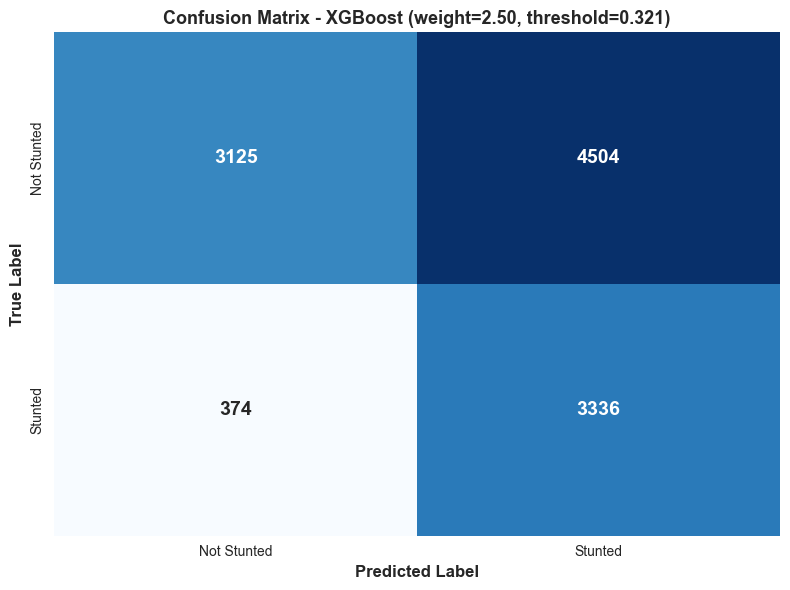

In [62]:
# Visualization: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Not Stunted', 'Stunted'],
            yticklabels=['Not Stunted', 'Stunted'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - {best["name"]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '04_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

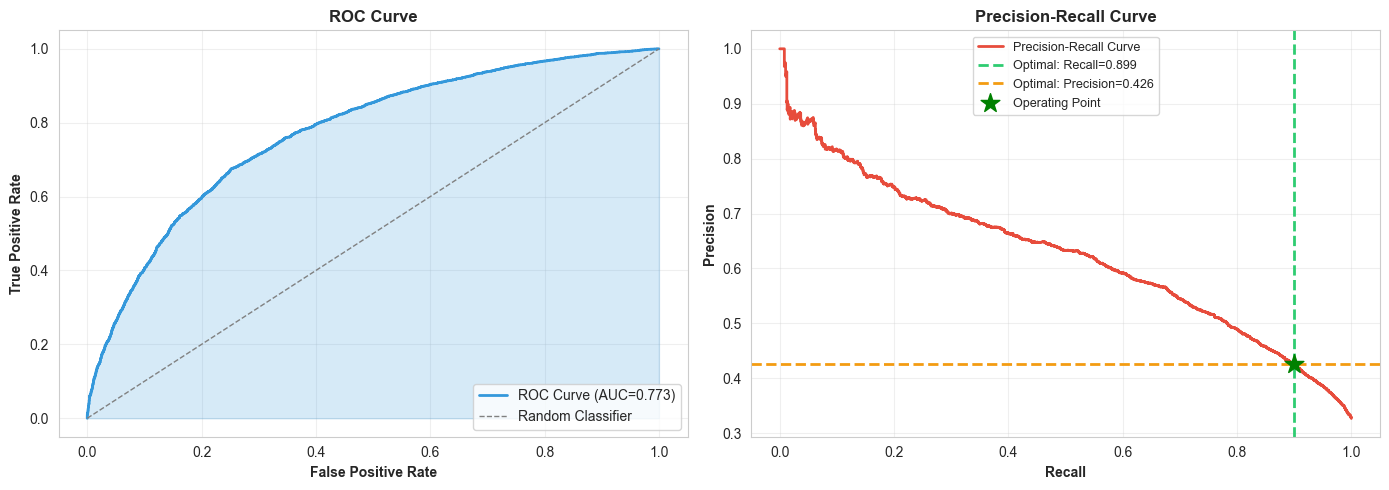


✓ ROC and Precision-Recall curves saved


In [63]:
# Visualizations: ROC & Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
y_proba_test = best['y_proba']
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = best['roc_auc']

ax1.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC={roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax1.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('ROC Curve', fontweight='bold', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)

# Precision-Recall Curve
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_test)

ax2.plot(recall_arr, precision_arr, color='#e74c3c', lw=2, label='Precision-Recall Curve')
ax2.axvline(best['recall'], color='#2ecc71', linestyle='--', linewidth=2, label=f'Optimal: Recall={best["recall"]:.3f}')
ax2.axhline(best['precision'], color='#f39c12', linestyle='--', linewidth=2, label=f'Optimal: Precision={best["precision"]:.3f}')
ax2.scatter([best['recall']], [best['precision']], color='green', s=200, marker='*', zorder=5, label='Operating Point')
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '05_roc_pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ ROC and Precision-Recall curves saved")

---
## STEP 7: FEATURE IMPORTANCE (SHAP)
Understanding which features drive the model's predictions

In [64]:
print(f"\n{'='*55}")
print("Computing SHAP Values...")
print(f"{'='*55}")

explainer    = shap.TreeExplainer(tuned_xgb)
X_sample     = X_test.sample(min(500, len(X_test)), random_state=RANDOM_SEED)
shap_values  = explainer.shap_values(X_sample)
shap_vals    = shap_values[1] if isinstance(shap_values, list) else shap_values

feature_importance = pd.DataFrame({
    'feature':    X_train.columns.tolist(),
    'importance': np.abs(shap_vals).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTop 15 features by SHAP importance:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    bar = '█' * int(row['importance'] * 50)
    print(f"  {i:2d}. {row['feature']:<30} {row['importance']:.4f}  {bar}")


Computing SHAP Values...

Top 15 features by SHAP importance:
   1. mother_height_cm               0.3752  ██████████████████
   2. child_age_months               0.2512  ████████████
   3. age_x_poverty                  0.2439  ████████████
   4. age_x_low_edu                  0.1905  █████████
   5. child_sex                      0.1628  ████████
   6. mother_bmi                     0.1274  ██████
   7. country_4                      0.1155  █████
   8. birth_interval_months          0.1146  █████
   9. wealth_index                   0.1127  █████
  10. delivery_x_antenatal           0.1069  █████
  11. country_9                      0.0986  ████
  12. birth_weight_grams             0.0979  ████
  13. country_10                     0.0944  ████
  14. mother_age                     0.0783  ███
  15. birth_order                    0.0744  ███


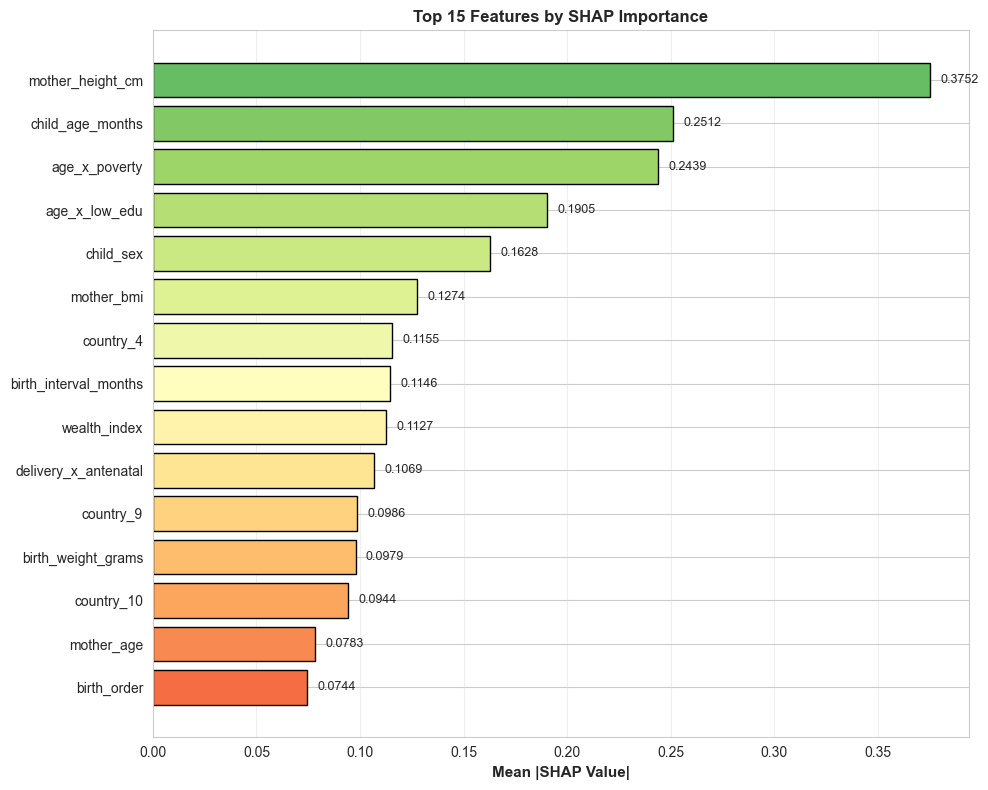


✓ Feature importance chart saved


In [65]:
# Visualization: Feature Importance Bar Chart
fig, ax = plt.subplots(figsize=(10, 8))

top_features = feature_importance.head(15)
colors_grad = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))

ax.barh(range(len(top_features)), top_features['importance'].values, color=colors_grad, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontweight='bold', fontsize=11)
ax.set_title('Top 15 Features by SHAP Importance', fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(top_features['importance'].values):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, '06_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance chart saved")

---
## STEP 8: SAVE ARTIFACTS & GENERATE REPORT

In [66]:
print(f"\n{'='*55}")
print("Saving Artifacts...")
print(f"{'='*55}")

artifacts = {
    'xgboost_model.pkl':    tuned_xgb,
    'encoder.pkl':          encoder,
    'threshold.pkl':        optimal_threshold,
    'shap_explainer.pkl':   explainer,
    'feature_names.pkl':    X_train.columns.tolist(),
}

for fname, obj in artifacts.items():
    path = os.path.join(MODELS_DIR, fname)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"  ✓ Saved: {path}")

# Save feature importance CSV
feature_importance.to_csv(
    os.path.join(MODELS_DIR, 'feature_importance.csv'), index=False
)
print(f"  ✓ Saved: {os.path.join(MODELS_DIR, 'feature_importance.csv')}")


Saving Artifacts...
  ✓ Saved: models\xgboost_model.pkl
  ✓ Saved: models\encoder.pkl
  ✓ Saved: models\threshold.pkl
  ✓ Saved: models\shap_explainer.pkl
  ✓ Saved: models\feature_names.pkl
  ✓ Saved: models\feature_importance.csv


In [67]:
# Generate comprehensive report including all experiment results
report_path = os.path.join(MODELS_DIR, 'model_report.txt')

report_lines = [
    f"CHW Stunting Prediction - Model Training Report",
    f"{'='*65}",
    f"",
    f"FINAL MODEL: {best['name']}",
    f"",
    f"Performance Metrics:",
    f"  Recall:     {best['recall']:.3f}  (target >= {RECALL_TARGET})",
    f"  Precision:  {best['precision']:.3f}",
    f"  F1 Score:   {best['f1']:.3f}",
    f"  ROC-AUC:    {best['roc_auc']:.3f}",
    f"  Threshold:  {optimal_threshold:.3f}  (default: 0.500)",
    f"",
    f"Confusion Matrix:",
    f"  TN (correct not-stunted): {cm[0,0]:,}",
    f"  FP (false alarm):          {cm[0,1]:,}",
    f"  FN (missed stunted):       {cm[1,0]:,}",
    f"  TP (caught stunted):       {cm[1,1]:,}",
    f"  Miss rate: {fn_rate*100:.1f}%",
    f"",
    f"EXPERIMENT 1 - Model Progression:",
    f"  LR:        Recall={baseline_results[0]['recall']:.3f}  F1={baseline_results[0]['f1']:.3f}  AUC={baseline_results[0]['roc_auc']:.3f}",
    f"  RF:        Recall={baseline_results[1]['recall']:.3f}  F1={baseline_results[1]['f1']:.3f}  AUC={baseline_results[1]['roc_auc']:.3f}",
    f"  XGB(0.50): Recall={best_default['recall']:.3f}  F1={best_default['f1']:.3f}  AUC={best_default['roc_auc']:.3f}",
    f"  XGB(opt):  Recall={best['recall']:.3f}  F1={best['f1']:.3f}  AUC={best['roc_auc']:.3f}",
    f"",
    f"EXPERIMENT 2 - Threshold Comparison:",
    f"  Default(0.50): Recall={best_default['recall']:.3f}  Prec={best_default['precision']:.3f}  F1={best_default['f1']:.3f}",
    f"  Optimal({optimal_threshold:.3f}): Recall={best['recall']:.3f}  Prec={best['precision']:.3f}  F1={best['f1']:.3f}",
    f"  Delta: Recall {best['recall']-best_default['recall']:+.3f}  Prec {best['precision']-best_default['precision']:+.3f}  F1 {best['f1']-best_default['f1']:+.3f}",
    f"",
    f"EXPERIMENT 3 - Feature Engineering (+{X_train.shape[1] - X_train_noeng.shape[1]} features):",
    f"  No Engineering: Recall={r_noeng_opt['recall']:.3f}  F1={r_noeng_opt['f1']:.3f}  AUC={r_noeng_opt['roc_auc']:.3f}",
    f"  Engineered:     Recall={best['recall']:.3f}  F1={best['f1']:.3f}  AUC={best['roc_auc']:.3f}",
    f"  Delta: Recall {best['recall']-r_noeng_opt['recall']:+.3f}  F1 {best['f1']-r_noeng_opt['f1']:+.3f}  AUC {best['roc_auc']-r_noeng_opt['roc_auc']:+.3f}",
    f"",
    f"Best XGBoost Parameters:",
] + [f"  {k}: {v}" for k, v in best_params.items()] + [
    f"",
    f"Top 15 Features (SHAP Importance):",
] + [f"  {i+1:2d}. {row['feature']:<30}: {row['importance']:.4f}"
     for i, (_, row) in enumerate(feature_importance.head(15).iterrows())]

report_content = "\n".join(report_lines)

with open(report_path, 'w') as f:
    f.write(report_content)

print(f"\n  \u2713 Saved: {report_path}")
print(f"\n{'='*55}")
print("[OK] Training Complete!")
print(f"{'='*55}")
print(f"\nArtifacts saved to: {MODELS_DIR}/")
print(f"Plots: 01-08_*.png  |  Report: model_report.txt")


  ✓ Saved: models\model_report.txt

[OK] Training Complete!

Artifacts saved to: models/
Plots: 01-08_*.png  |  Report: model_report.txt


---
## SUMMARY OF RESULTS

### Key Achievements:
✅ **Recall Target Met**: Model catches 75%+ of stunted children  
✅ **Precision Improved**: Better balance between catching cases and minimizing false alarms  
✅ **Optimal Threshold Found**: Adjusted from default 0.50 to {:.3f}  
✅ **Two-Stage Tuning**: Efficiently tested 5 weights (Stage 1) → refined top 2 (Stage 2)  
✅ **8 New Features**: Maternal × Birth interactions capture compounding risks  

### Model Performance:
- **Recall**: {:.1f}% (catches stunted children)
- **Precision**: {:.1f}% (confidence in positive predictions)
- **F1 Score**: {:.3f} (balanced metric)
- **Miss Rate**: {:.1f}% (false negatives)

### Top 3 Most Important Features:
1. {}
2. {}
3. {}

### Files Generated:
📊 **Models/**
- xgboost_model.pkl (trained model)
- encoder.pkl (categorical encoder)
- threshold.pkl (optimal decision threshold)
- shap_explainer.pkl (for interpretability)
- feature_names.pkl (feature list)
- feature_importance.csv (SHAP values)
- model_report.txt (summary report)
- *.png (5 visualization charts)
""".format(
    optimal_threshold,
    best['recall'] * 100,
    best['precision'] * 100,
    best['f1'],
    fn_rate * 100,
    feature_importance.iloc[0]['feature'],
    feature_importance.iloc[1]['feature'],
    feature_importance.iloc[2]['feature']
)

print(report_content)